In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load datasets
mitbih_train = pd.read_csv("mitbih_train.csv", header=None)
mitbih_test = pd.read_csv("mitbih_test.csv", header=None)
ptbdb_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)
ptbdb_normal = pd.read_csv("ptbdb_normal.csv", header=None)

# Print dataset shapes
print(f"MIT-BIH Train Shape: {mitbih_train.shape}")
print(f"MIT-BIH Test Shape: {mitbih_test.shape}")
print(f"PTBDB Abnormal Shape: {ptbdb_abnormal.shape}")
print(f"PTBDB Normal Shape: {ptbdb_normal.shape}")

# Display first 5 rows from each file
print("\nMIT-BIH Train Sample:")
print(mitbih_train.head())

print("\nMIT-BIH Test Sample:")
print(mitbih_test.head())

print("\nPTBDB Abnormal Sample:")
print(ptbdb_abnormal.head())

print("\nPTBDB Normal Sample:")
print(ptbdb_normal.head())


MIT-BIH Train Shape: (87554, 188)
MIT-BIH Test Shape: (21892, 188)
PTBDB Abnormal Shape: (10506, 188)
PTBDB Normal Shape: (4046, 188)

MIT-BIH Train Sample:
        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0 

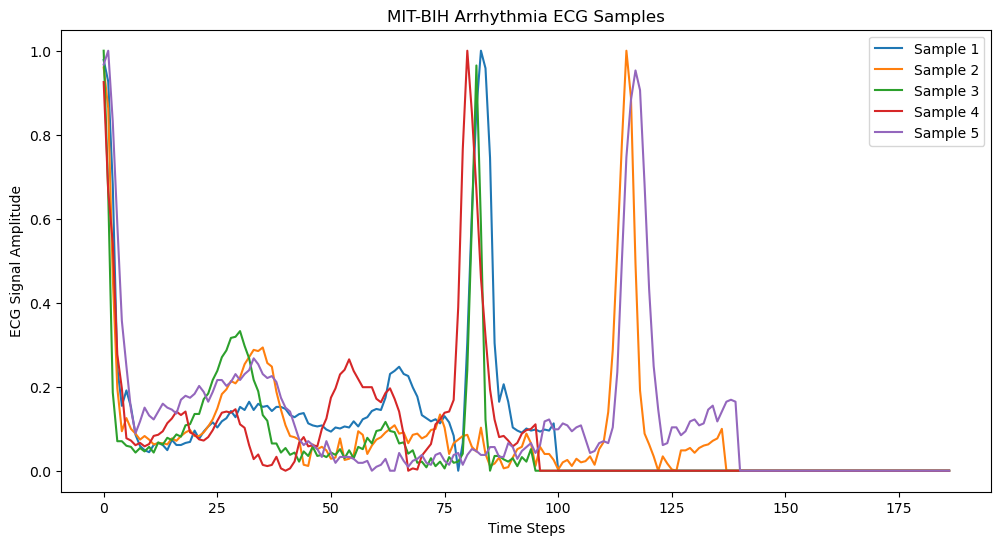

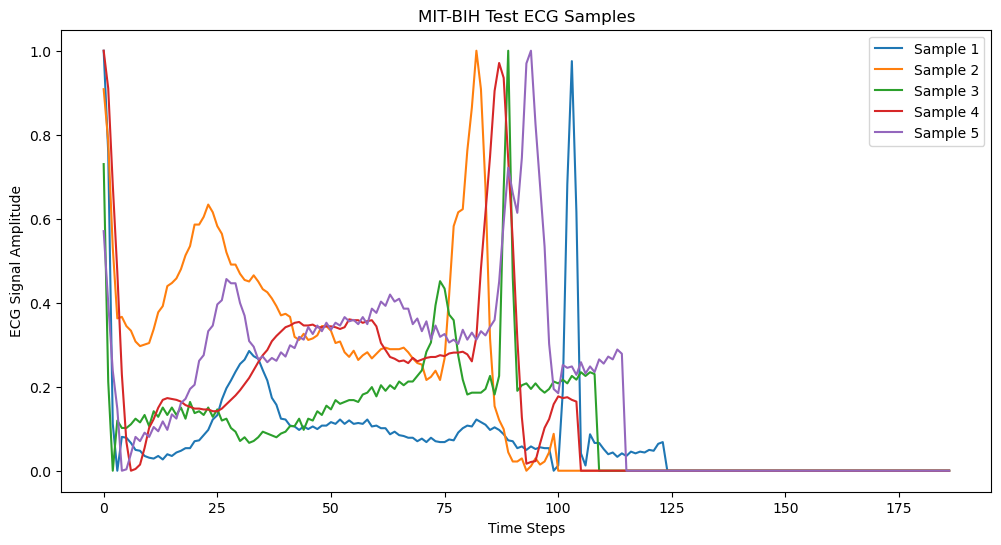

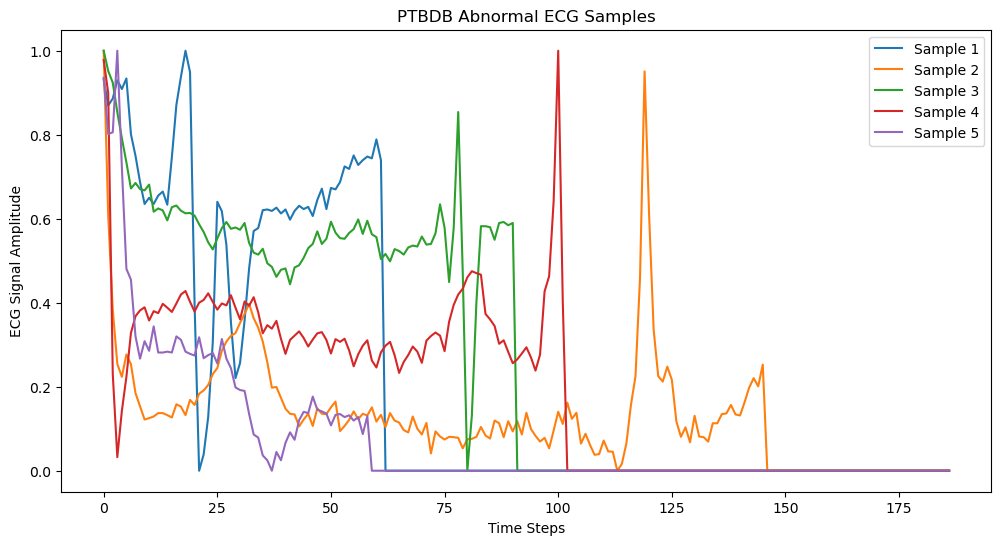

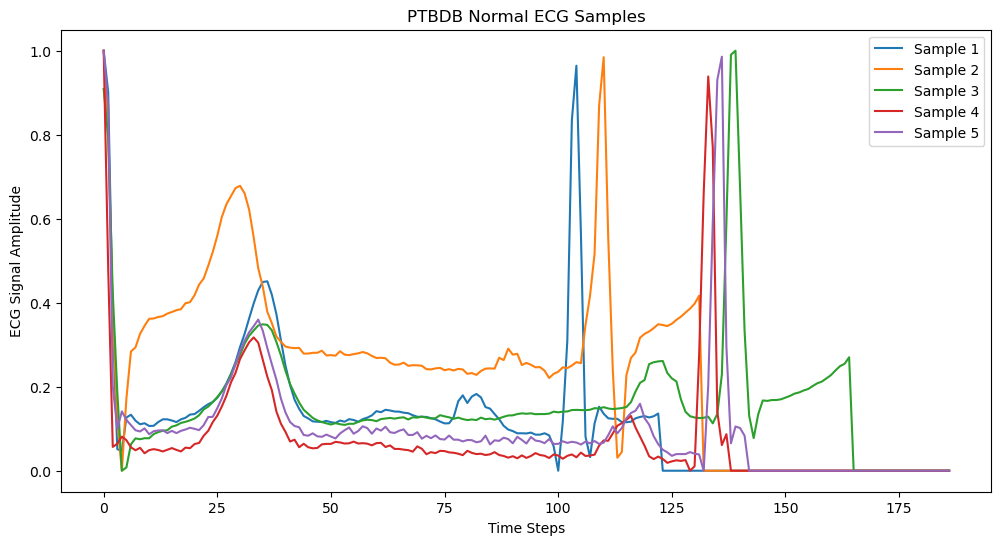

In [2]:
def plot_ecg_samples(df, title, num_samples=5):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        plt.plot(df.iloc[i, :-1], label=f"Sample {i+1}")
    
    plt.title(title)
    plt.xlabel("Time Steps")
    plt.ylabel("ECG Signal Amplitude")
    plt.legend()
    plt.show()

# Plot samples from each dataset
plot_ecg_samples(mitbih_train, "MIT-BIH Arrhythmia ECG Samples")
plot_ecg_samples(mitbih_test, "MIT-BIH Test ECG Samples")
plot_ecg_samples(ptbdb_abnormal, "PTBDB Abnormal ECG Samples")
plot_ecg_samples(ptbdb_normal, "PTBDB Normal ECG Samples")


In [3]:
import pandas as pd



df_train = pd.read_csv("mitbih_train.csv", header=None)
df_test = pd.read_csv("mitbih_test.csv", header=None)

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)


Train Shape: (87554, 188)
Test Shape: (21892, 188)


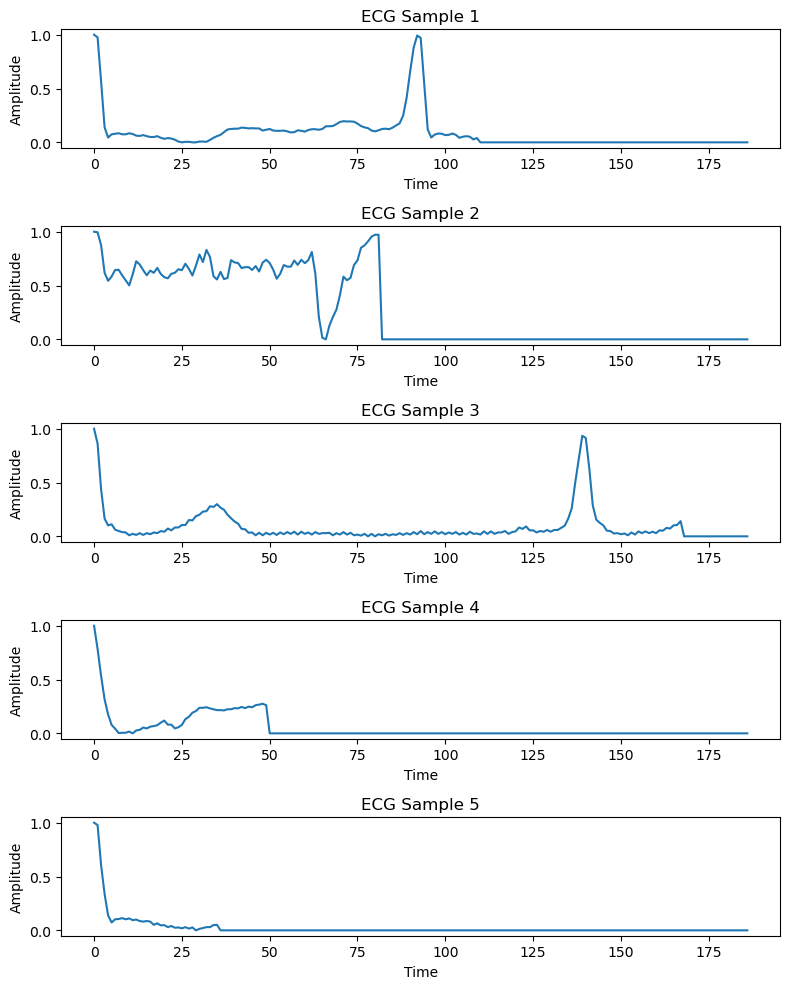

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Select random samples
num_samples = 5  # You can change this number
indices = np.random.choice(df_train.shape[0], num_samples, replace=False)

plt.figure(figsize=(8, 10))

for i, idx in enumerate(indices, 1):
    plt.subplot(num_samples, 1, i)
    plt.plot(df_train.iloc[idx, :-1].values)  # All but the last column
    plt.title(f"ECG Sample {i}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (ECG signals) and labels (last column)
X_train = df_train.iloc[:, :-1].values
y_train = df_train.iloc[:, -1].values
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# Normalize the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # Use same scaler as train data

# Split training data into train/validation sets (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Print shapes to verify
print(f"Train Data Shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation Data Shape: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test Data Shape: {X_test.shape}, Labels: {y_test.shape}")


Train Data Shape: (70043, 187), Labels: (70043,)
Validation Data Shape: (17511, 187), Labels: (17511,)
Test Data Shape: (21892, 187), Labels: (21892,)


In [6]:
import torch

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Create DataLoader for batching
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)


In [8]:
import torch.nn as nn
import torch.optim as optim

class ECG_MLP(nn.Module):
    def __init__(self):
        super(ECG_MLP, self).__init__()
        self.fc1 = nn.Linear(187, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 5)  # 5 classes
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return self.softmax(x)

# Move model to GPU
model = ECG_MLP().to(device)
print(model)


ECG_MLP(
  (fc1): Linear(in_features=187, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=5, bias=True)
  (softmax): Softmax(dim=1)
)


In [9]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Train Acc: {train_acc:.2f}%")


Epoch [1/20], Loss: 2201.5258, Train Acc: 90.18%
Epoch [2/20], Loss: 2168.4202, Train Acc: 91.42%
Epoch [3/20], Loss: 2165.8085, Train Acc: 91.53%
Epoch [4/20], Loss: 2163.5576, Train Acc: 91.64%
Epoch [5/20], Loss: 2163.2991, Train Acc: 91.65%
Epoch [6/20], Loss: 2165.5768, Train Acc: 91.54%
Epoch [7/20], Loss: 2163.3752, Train Acc: 91.65%
Epoch [8/20], Loss: 2166.4803, Train Acc: 91.50%
Epoch [9/20], Loss: 2162.0492, Train Acc: 91.71%
Epoch [10/20], Loss: 2161.6015, Train Acc: 91.73%
Epoch [11/20], Loss: 2161.7208, Train Acc: 91.72%
Epoch [12/20], Loss: 2161.3987, Train Acc: 91.74%
Epoch [13/20], Loss: 2160.4744, Train Acc: 91.78%
Epoch [14/20], Loss: 2161.7877, Train Acc: 91.72%
Epoch [15/20], Loss: 2160.9489, Train Acc: 91.76%
Epoch [16/20], Loss: 2158.8572, Train Acc: 91.86%
Epoch [17/20], Loss: 2158.2666, Train Acc: 91.88%
Epoch [18/20], Loss: 2161.3293, Train Acc: 91.74%
Epoch [19/20], Loss: 2159.5414, Train Acc: 91.83%
Epoch [20/20], Loss: 2160.7568, Train Acc: 91.77%


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 91.99%


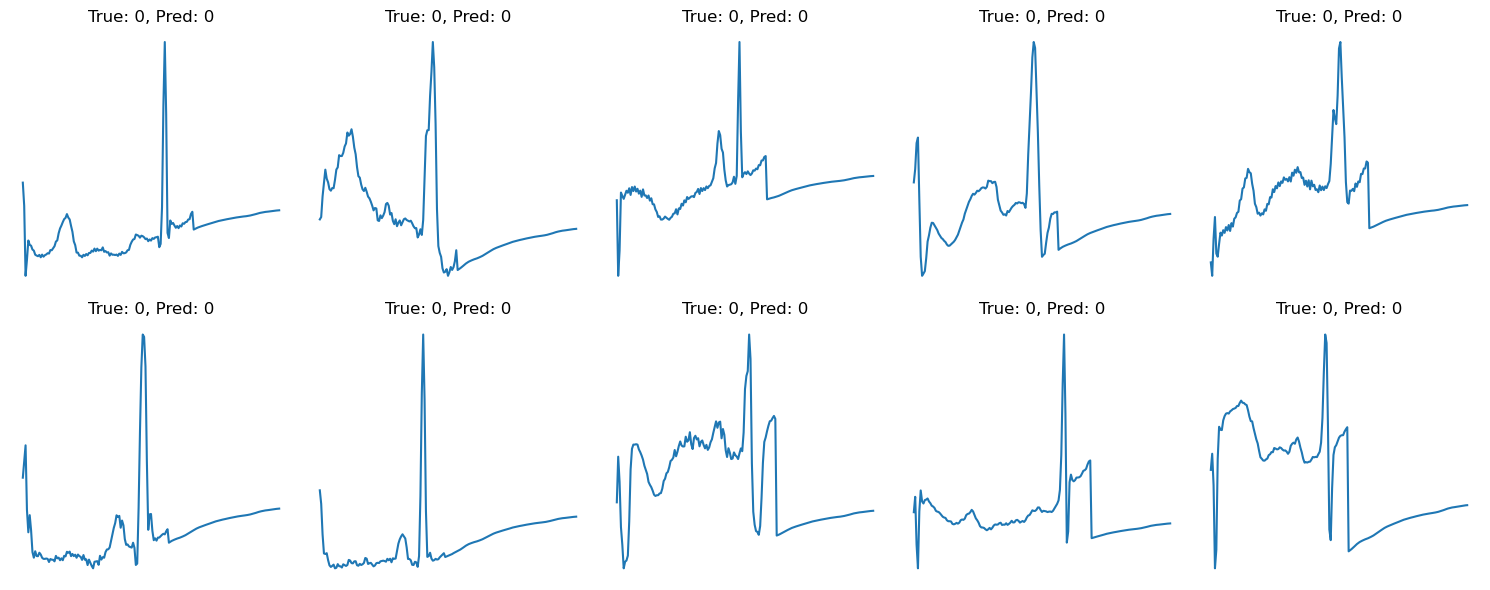

In [11]:
import matplotlib.pyplot as plt

# Get some test samples
test_samples, test_labels = next(iter(test_loader))
test_samples = test_samples[:10]  # Pick first 10 samples

# Get model predictions
model.eval()
with torch.no_grad():
    outputs = model(test_samples)
    _, preds = torch.max(outputs, 1)

# Plot results
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].plot(test_samples[i].cpu().numpy().flatten())
    axes[i].set_title(f"True: {test_labels[i].item()}, Pred: {preds[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


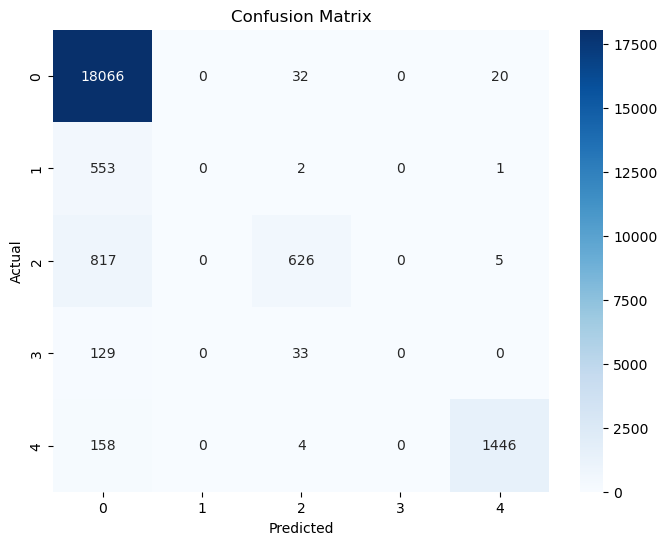

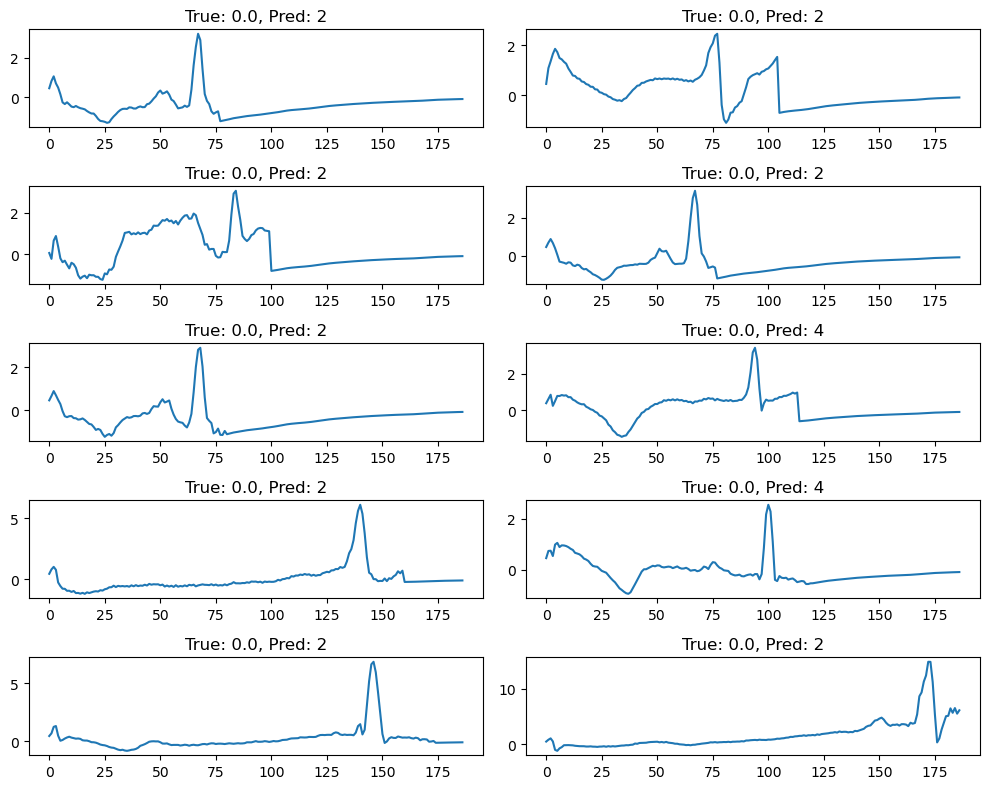

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions
model.eval()
with torch.no_grad():
    test_inputs_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_outputs = model(test_inputs_tensor)
    predicted_labels = torch.argmax(test_outputs, axis=1).cpu().numpy()

# Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Identify misclassified examples
misclassified_idx = np.where(y_test != predicted_labels)[0]

# Plot 10 misclassified ECG signals
num_misclassified = min(10, len(misclassified_idx))
plt.figure(figsize=(10, 8))
for i in range(num_misclassified):
    idx = misclassified_idx[i]
    plt.subplot(5, 2, i + 1)
    plt.plot(X_test[idx])
    plt.title(f"True: {y_test[idx]}, Pred: {predicted_labels[idx]}")
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Function to extract statistical features from ECG signals
def extract_stat_features(data):
    features = {
        "mean": np.mean(data, axis=1),
        "std": np.std(data, axis=1),
        "variance": np.var(data, axis=1),
        "skewness": skew(data, axis=1),
        "kurtosis": kurtosis(data, axis=1),
        "rms": np.sqrt(np.mean(data**2, axis=1))
    }
    return pd.DataFrame(features)

# Extract features from train and test sets
train_features = extract_stat_features(X_train)  # X_train = ECG signal data
test_features = extract_stat_features(X_test)    # X_test = ECG signal data

# Display first few rows
print(train_features.head())
print('\n')
print(test_features.head())


       mean       std  variance  skewness   kurtosis       rms
0 -0.084767  0.575351  0.331029  1.442181   4.237287  0.581562
1  0.058847  0.454118  0.206223  0.307941   0.195153  0.457915
2  0.619137  0.784525  0.615480  0.818814   1.962829  0.999405
3 -0.130825  0.498197  0.248200  2.185507  12.408815  0.515088
4 -0.442548  0.557701  0.311030  3.175923  14.457743  0.711955


       mean       std  variance  skewness   kurtosis       rms
0 -0.494615  0.490095  0.240193  3.434529  21.054438  0.696303
1  0.076703  0.719678  0.517936  1.494704   2.539104  0.723754
2 -0.340583  0.507841  0.257902  1.637231  12.985208  0.611473
3 -0.107301  0.589498  0.347508  2.500468   8.868743  0.599184
4  0.075481  0.681208  0.464044  1.879047   6.461108  0.685377


In [17]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Function to extract morphological features from ECG signals
def extract_morph_features(ecg_signals):
    features_list = []
    
    for signal in ecg_signals:
        # Detect R-peaks (prominent peaks in ECG)
        peaks, _ = find_peaks(signal, height=np.mean(signal) + np.std(signal))  
        
        if len(peaks) < 2:
            # Skip signals where peaks are not detected
            features_list.append([0, 0, 0, 0, 0, 0])
            continue
        
        # Compute RR intervals (time between R-peaks)
        rr_intervals = np.diff(peaks)
        avg_rr = np.mean(rr_intervals) if len(rr_intervals) > 0 else 0
        
        # Compute QRS duration (approximate width of QRS complex)
        qrs_duration = np.std(rr_intervals) if len(rr_intervals) > 0 else 0
        
        # Compute R-peak amplitude
        r_peak_amplitude = np.max(signal[peaks]) if len(peaks) > 0 else 0
        
        # Compute ST segment deviation (difference in ST region)
        st_deviation = np.mean(signal[peaks[-5:]]) - np.mean(signal[:5])
        
        # Append to feature list
        features_list.append([r_peak_amplitude, avg_rr, qrs_duration, st_deviation, np.max(signal), np.min(signal)])

    # Convert to DataFrame
    features_df = pd.DataFrame(features_list, columns=["R_peak", "Avg_RR", "QRS_Duration", "ST_Deviation", "Max_Signal", "Min_Signal"])
    return features_df

# Extract features from train and test sets
train_morph_features = extract_morph_features(X_train)  # X_train = ECG signals
test_morph_features = extract_morph_features(X_test)    # X_test = ECG signals

# Display first few rows
print(train_morph_features.head())
print('\n')
print(test_morph_features.head())

     R_peak  Avg_RR  QRS_Duration  ST_Deviation  Max_Signal  Min_Signal
0  2.603879   31.00     44.485953      0.621269    2.603879   -1.235725
1  0.000000    0.00      0.000000      0.000000    0.000000    0.000000
2  3.952619    9.00      3.000000      2.651067    3.952619   -1.032632
3  3.247592   10.75     17.217360      1.840338    3.247592   -1.619625
4  2.986473   83.00      0.000000      1.402058    2.986473   -1.157064


     R_peak     Avg_RR  QRS_Duration  ST_Deviation  Max_Signal  Min_Signal
0  0.000000   0.000000      0.000000      0.000000    0.000000    0.000000
1  3.134425  19.500000     22.940139      1.232912    3.134425   -0.897895
2  3.095110  11.333333      4.496913      2.364314    3.095110   -2.460512
3  2.871915  42.000000      9.000000      0.796320    2.871915   -1.153115
4  3.440919  12.000000      7.000000      3.137812    3.440919   -1.617728


C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

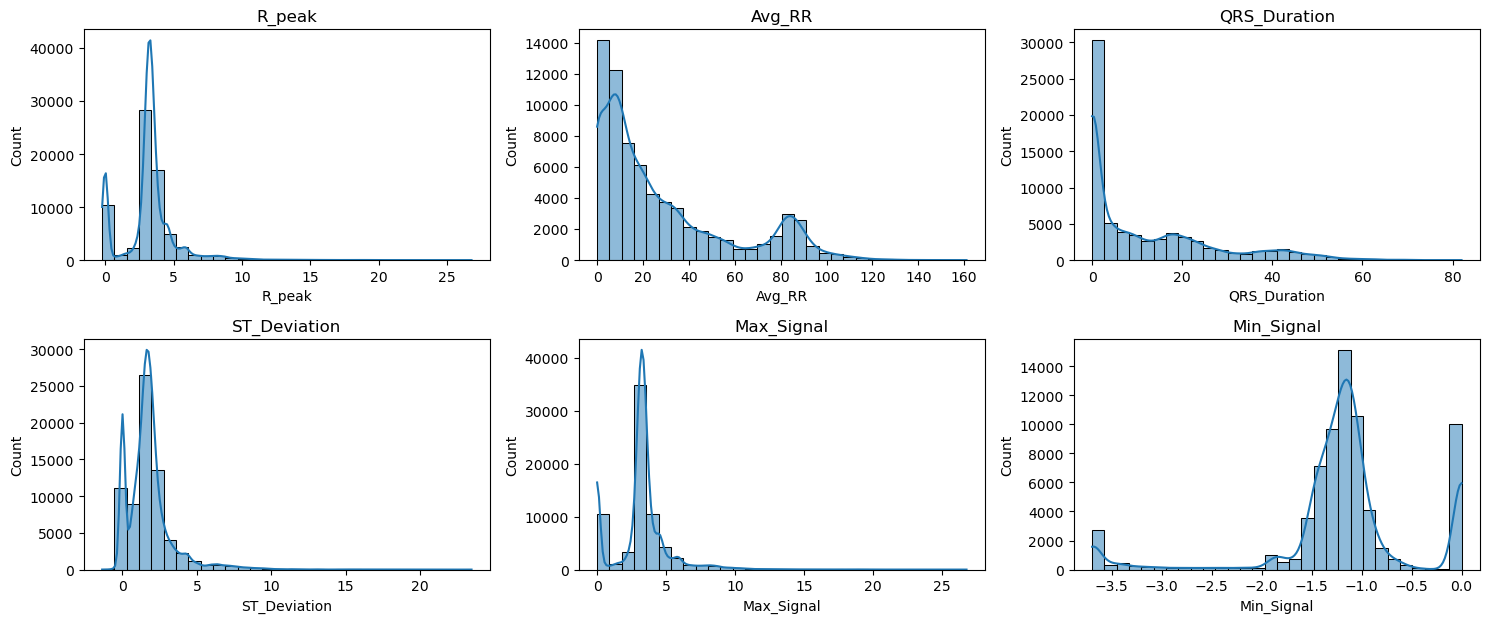

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the number of features per row for visualization
num_features = len(train_morph_features.columns)
num_rows = (num_features // 3) + 1  # Arrange in a grid of 3 columns

plt.figure(figsize=(15, num_rows * 3))

for i, feature in enumerate(train_morph_features.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(train_morph_features[feature], kde=True, bins=30)
    plt.title(feature)

plt.tight_layout()
plt.show()


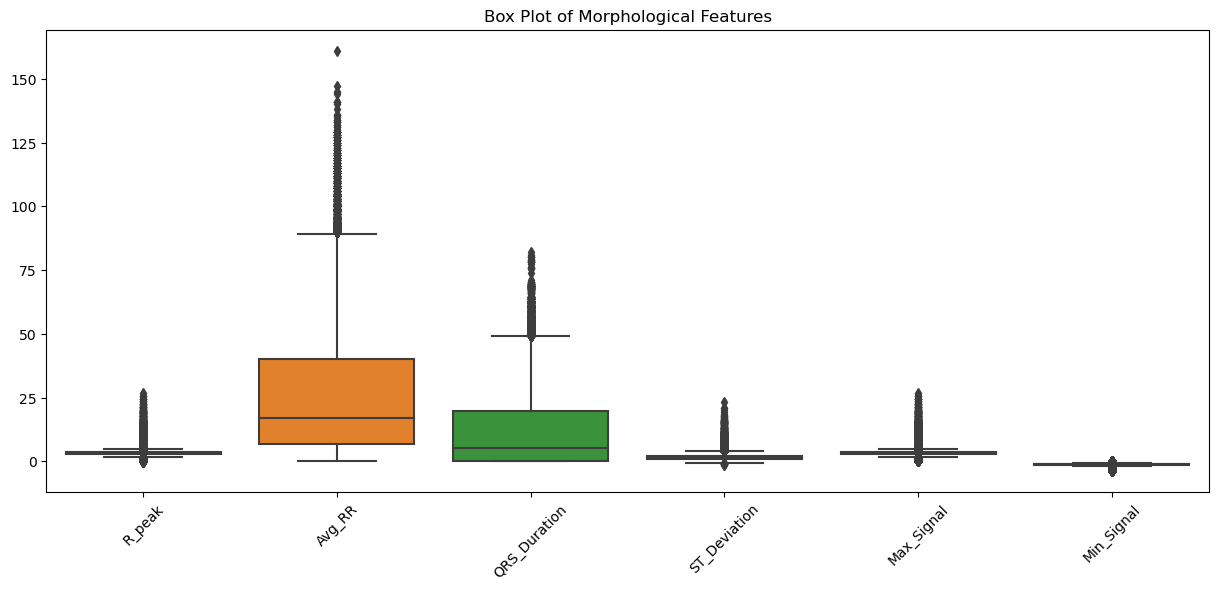

In [19]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train_morph_features)
plt.xticks(rotation=45)
plt.title("Box Plot of Morphological Features")
plt.show()


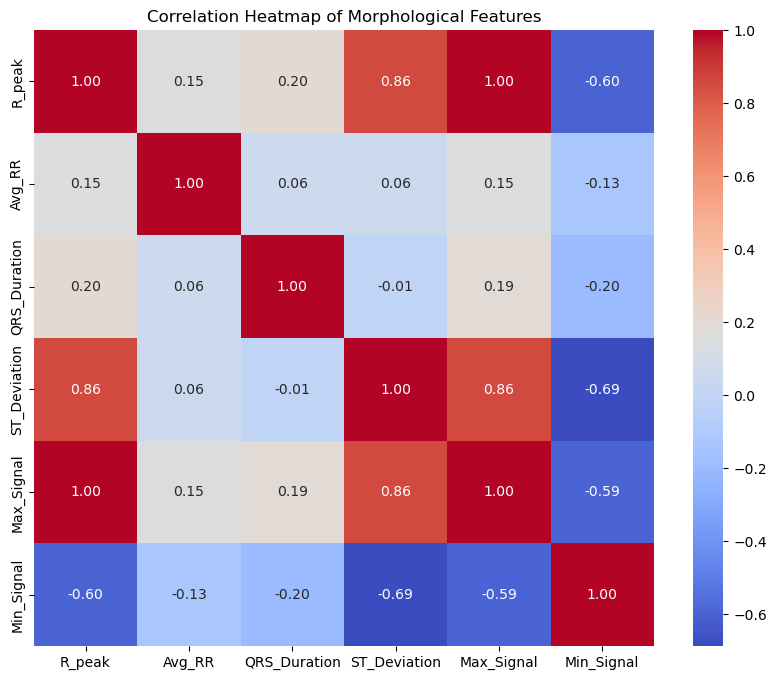

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_morph_features.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Morphological Features")
plt.show()


C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

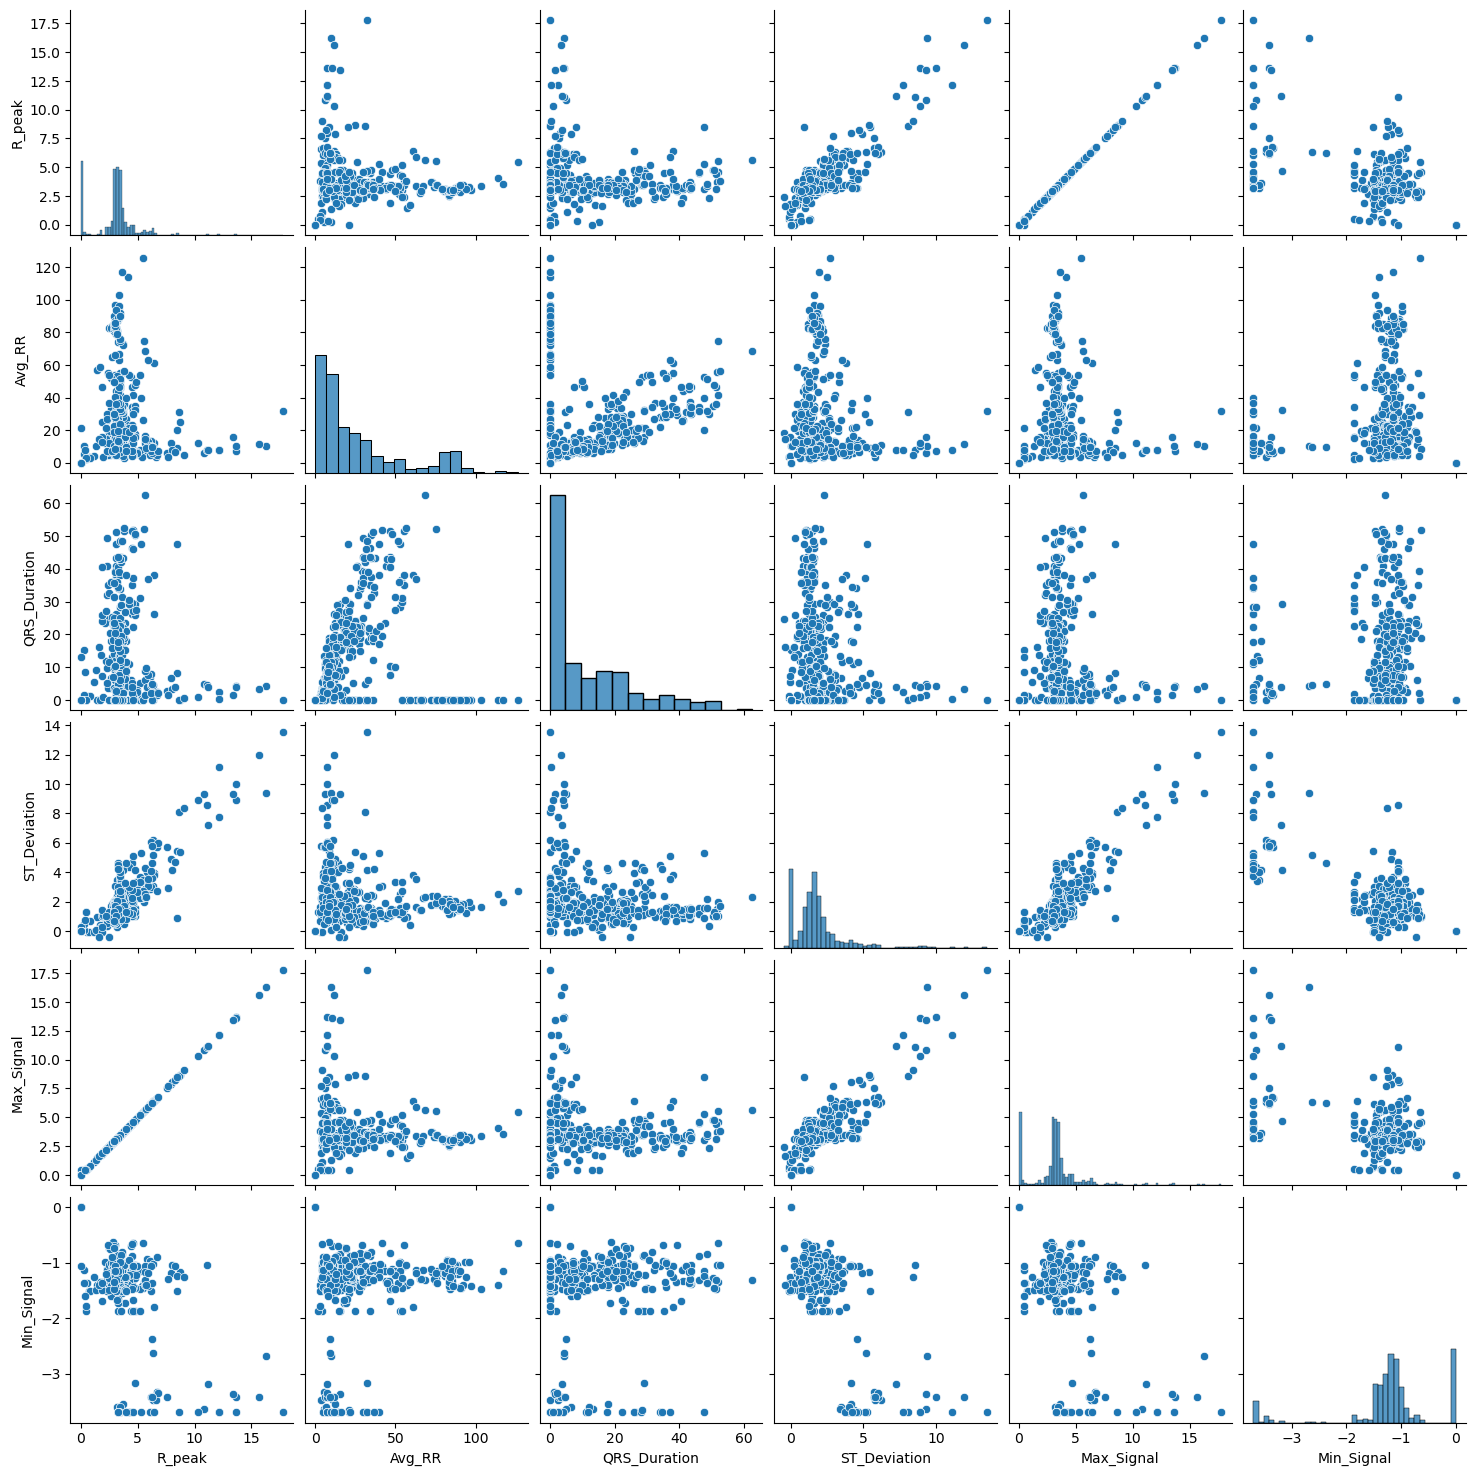

In [21]:
sns.pairplot(train_morph_features.sample(500))  # Use a smaller sample for faster plotting
plt.show()
